In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cu128'

In [ ]:
weight = 0.7
bias = 0.3
start =1
end =50
step=0.043
x=torch.linspace(0 , 1  , 50).unsqueeze(dim=1)
y = weight*x + bias
x , y

(tensor([[0.0000],
         [0.0204],
         [0.0408],
         [0.0612],
         [0.0816],
         [0.1020],
         [0.1224],
         [0.1429],
         [0.1633],
         [0.1837],
         [0.2041],
         [0.2245],
         [0.2449],
         [0.2653],
         [0.2857],
         [0.3061],
         [0.3265],
         [0.3469],
         [0.3673],
         [0.3878],
         [0.4082],
         [0.4286],
         [0.4490],
         [0.4694],
         [0.4898],
         [0.5102],
         [0.5306],
         [0.5510],
         [0.5714],
         [0.5918],
         [0.6122],
         [0.6327],
         [0.6531],
         [0.6735],
         [0.6939],
         [0.7143],
         [0.7347],
         [0.7551],
         [0.7755],
         [0.7959],
         [0.8163],
         [0.8367],
         [0.8571],
         [0.8776],
         [0.8980],
         [0.9184],
         [0.9388],
         [0.9592],
         [0.9796],
         [1.0000]]),
 tensor([[0.3000],
         [0.3143],
         [

In [ ]:
len(x) , len(y)

(50, 50)

In [ ]:
# test and train set
train_split = int(0.8*len(x))
x_train , y_train = x[:train_split] , y[:train_split]
x_test, y_test = x[train_split:] , y[train_split:]
len(x_train) , len(y_train) , len(x_test) , len(y_test)


(40, 40, 10, 10)

In [ ]:
# visualize the data
def plot_predictions(train_data=x_train , train_labels=y_train  , test_data = x_test , test_labels=y_test , predictions=None):
  # ploting the data in gra
  plt.figure(figsize=(10 , 7))
  plt.scatter(train_data , train_labels , c='b' , s=4 , label='training data')
  plt.scatter(test_data , test_labels , c='r' , s =4 , label = 'test data')


  if predictions is not None:
    plt.scatter(test_data , predictions , c='g' , s=4 , label='prediction data')
  plt.legend(prop={'size':14})
  plt.show()
  # plot_predictions()

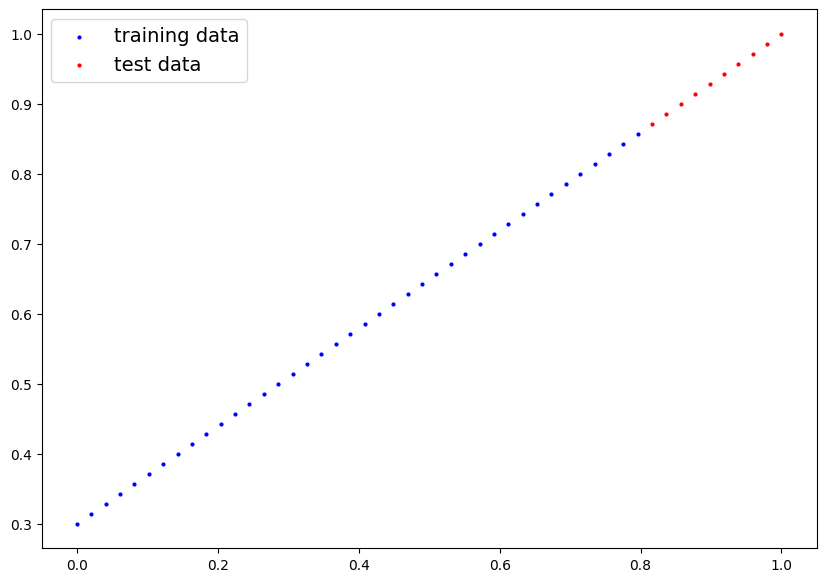

In [ ]:
plot_predictions()

In [ ]:
from torch  import nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1 , requires_grad = True , dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1 , requires_grad =True , dtype = torch.float))

  def forward(self , x:torch.tensor)->torch.tensor:
    return self.weights*x+self.bias

In [ ]:
#checking insie module
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
x_test , y_test

(tensor([[0.8163],
         [0.8367],
         [0.8571],
         [0.8776],
         [0.8980],
         [0.9184],
         [0.9388],
         [0.9592],
         [0.9796],
         [1.0000]]),
 tensor([[0.8714],
         [0.8857],
         [0.9000],
         [0.9143],
         [0.9286],
         [0.9429],
         [0.9571],
         [0.9714],
         [0.9857],
         [1.0000]]))

In [ ]:
with torch.inference_mode():
  y_preds = model_0(x_test)


y_preds

tensor([[0.4037],
        [0.4105],
        [0.4174],
        [0.4243],
        [0.4311],
        [0.4380],
        [0.4449],
        [0.4518],
        [0.4586],
        [0.4655]])

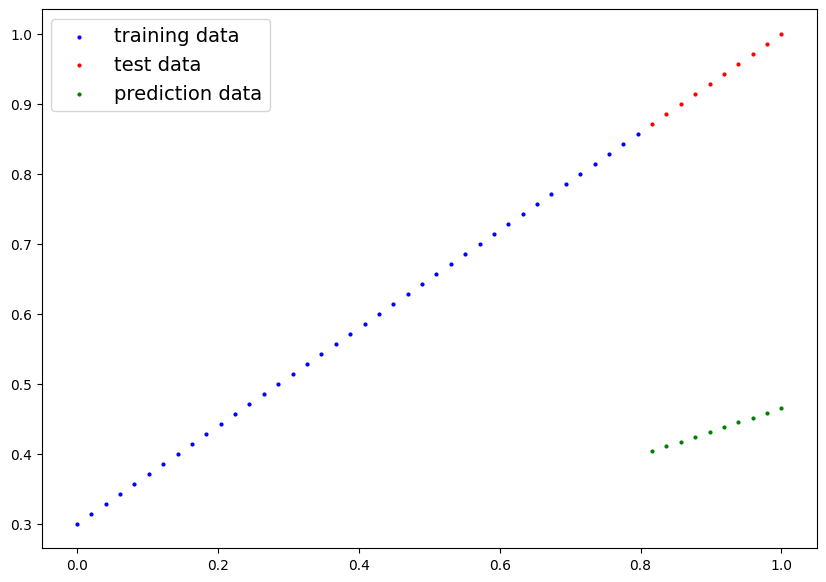

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters() , lr=0.01)

In [ ]:
#loss , gd , ...

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters() , lr=0.01)
epoch_count = []
loss_values = []
test_loss_values = []
epochs = 1000
for epoch in range(epochs):
  model_0.train() #training mod e
  y_preds = model_0(x_train)  #prediction
  loss = loss_fn(y_preds , y_train)  #inputs and then targets
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


  #for testing the model
  model_0.eval() #turns of the gradient tracking
  with torch.inference_mode():
    test_pred = model_0(x_test)


    test_loss = loss_fn(test_pred , y_test)
  if(epoch%100==0):
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())
    print(f"epoch: {epoch} loss: {loss.item():.10f} test_loss: {test_loss.item():.10f}")
print(f"loss: {loss.item():.4f}")

epoch: 0 loss: 0.3157730103 test_loss: 0.4875209332
epoch: 100 loss: 0.0240358282 test_loss: 0.0555960350
epoch: 200 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 300 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 400 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 500 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 600 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 700 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 800 loss: 0.0036018596 test_loss: 0.0109206494
epoch: 900 loss: 0.0036018596 test_loss: 0.0109206494
loss: 0.0080


In [ ]:
model_0.state_dict()


OrderedDict([('weights', tensor([0.6982])), ('bias', tensor([0.3043]))])

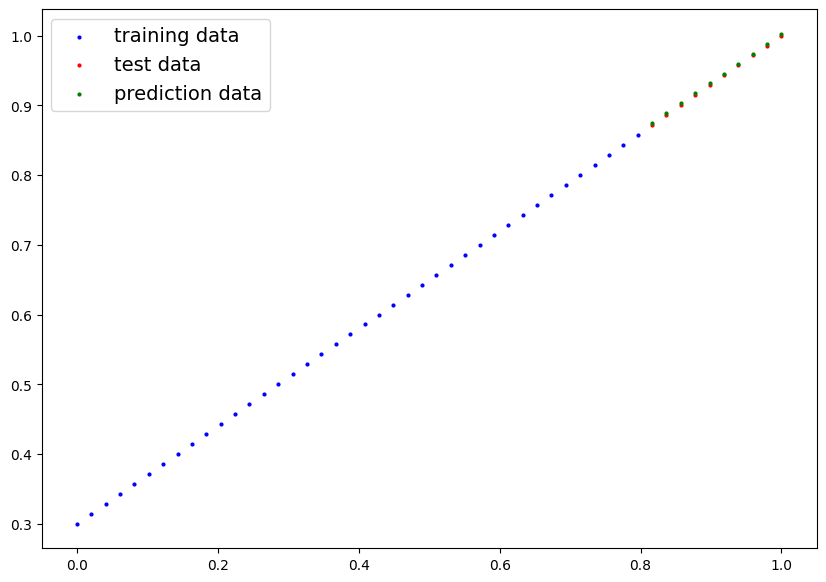

In [ ]:
with torch.no_grad():
  y_preds2 = model_0(x_test)
y_preds2 , y_test
plot_predictions(predictions=y_preds2.detach())

In [ ]:
test_loss

tensor(0.0027)

Text(0, 0.5, 'Loss Value')

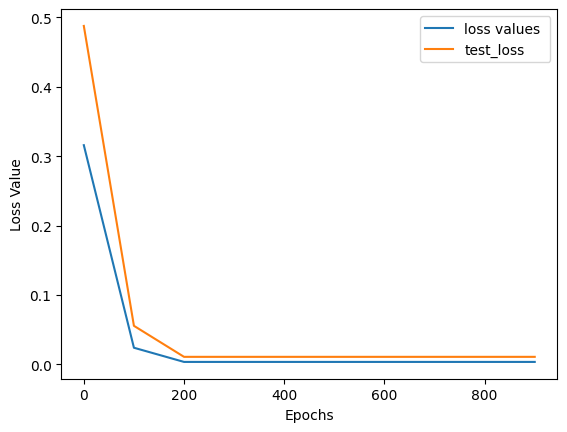

In [ ]:
plt.plot(epoch_count , loss_values , label='loss values ')
plt.plot(epoch_count , test_loss_values , label='test_loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss Value')

In [ ]:
from pathlib import Path
model_path = Path("models")
model_path.mkdir(parents=True , exist_ok=True) # Changed from model_path.parent.mkdir() to model_path.mkdir() as model_path is the directory.
model_name= "model_0.pth"
model_save_path = model_path/model_name
print(f"saving model to {model_save_path}")
torch.save(obj=model_0.state_dict() , f=model_save_path)

saving model to models/model_0.pth


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Loading the model


In [ ]:
#loading the saved state dict ..

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6982])), ('bias', tensor([0.3043]))])

In [ ]:
#to load we have to intentiate the new instance of our model
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6982])), ('bias', tensor([0.3043]))])

In [ ]:
loaded_model_0.eval()
with torch.no_grad():
  loaded_model_preds=loaded_model_0(x_test)

loaded_model_preds , y_test

(tensor([[0.8743],
         [0.8885],
         [0.9028],
         [0.9170],
         [0.9313],
         [0.9455],
         [0.9598],
         [0.9740],
         [0.9883],
         [1.0025]]),
 tensor([[0.8714],
         [0.8857],
         [0.9000],
         [0.9143],
         [0.9286],
         [0.9429],
         [0.9571],
         [0.9714],
         [0.9857],
         [1.0000]]))

In [ ]:
loaded_model_preds==y_test

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])